# 🛒 Caso Semestral - RetailSmart
## Análisis de Clientes para una Cadena de Comercio
### Machine Learning - MLY0100 | DUOC UC

---

| Campo | Detalle |
|---|---|
| **Integrante 1** | _Francisco Jesús Aranguiz Inostroza_ |
| **Integrante 2** | _Vicente Benjamin Alarcón Gallardo_ |
| **Sección** | _003D_OLS_ |
| **Docente** | _Joan Manuel Toro Ortiz_ |
| **Fecha de entrega** | **_POR DEFINIR_** |
| **Evaluación** | Parcial 1 - Entrega Grupal (70%) |

---

### 📋 Descripción del trabajo

> _(Escriban aquí un párrafo breve describiendo qué hicieron en este notebook, qué decisiones tomaron y cuáles fueron los hallazgos más relevantes.)_

---
# FASE 1 — Comprensión del Negocio
### `CRISP-DM: Business Understanding`

En esta fase debemos entender el contexto del negocio antes de tocar cualquier dato.  
El objetivo es responder: **¿qué problema queremos resolver y por qué importa?**

## 1.1 Contexto de RetailSmart

> _(Describan con sus propias palabras el contexto del negocio. ¿Qué hace RetailSmart? ¿En qué regiones opera? ¿Qué canales usa? ¿Cuál es el problema que enfrenta?)_

**R:**

RetailSmart es una empresa del sector minorista que opera en **5 regiones de Chile** (**Metropolitana, Valparaíso, Biobío, Araucanía y Coquimbo**), operando mediante tiendas fisicas, plataforma online y aplicación móvil. La empresa ha acumulado una importante base de datos históricos sobre sus clientes, incluyendo información demográfica y comportamiento de compra. En el entorno competitivo actual, la empresa busca modernizar su estrategia pasando de una toma de decisiones basada en la intuición a un enfoque Data-Driven (Tomar decisiones basandose en los datos recopilados con anterioridad). El desafío principal es utilizar esta información para optimizar las campañas de marketing, mejorar la retención y proyectar el valor económico de sus consumidores.

## 1.2 Objetivos del Proyecto

> _(Definan al menos 3 objetivos analíticos concretos del proyecto. Deben conectar con las tareas de ML que realizarán.)_

**R:**


- **Objetivo 1:** Pronosticar el gasto anual del cliente. 
- **Objetivo 2:** Predecir el estado de actividad del cliente.
- **Objetivo 3:** Clasificar los segmentos de consumidores.

## 1.3 Identificación de Targets

Para este proyecto se trabajará con tres targets distintos a lo largo del semestre:

| Target | Variable | Tipo de tarea | Justificación |
|---|---|---|---|
| Gasto anual del cliente | `gasto_anual` | Regresión | _Usamos regresión para predecir un número continuo._ |
| Estado del cliente | `cliente_activo` | Clasificación binaria | _Usamos una clasificación binaria ya que trabajaremos con solo DOS opciones._ |
| Segmento del cliente | `segmento_cliente` | Clasificación multiclase | _Usamos esta clasificación multiclase para categorizar a los clientes._ |

> **Para esta entrega (Parcial 1) el foco es el EDA y preprocesamiento, no el modelado.**

---
# FASE 2 — Comprensión de los Datos
### `CRISP-DM: Data Understanding`

En esta fase exploramos el dataset para entender su estructura, calidad y características.  
El objetivo es detectar patrones, anomalías y oportunidades antes de modelar.

## 2.1 Importación de Librerías

In [1]:
# Librerías de manipulación de datos
import pandas as pd
import numpy as np

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de preprocesamiento (se usarán en Fase 3)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer

# Configuraciones generales
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 2.2 Carga del Dataset

**Instrucciones para cargar el archivo en Google Colab:**
1. Descarga el archivo `retail_clientes_MLY0100.csv` desde AVA
2. Ejecuta la celda siguiente — aparecerá un botón para seleccionar el archivo
3. Selecciona el CSV descargado
4. El archivo quedará disponible en el entorno de Colab

In [ ]:
# Carga del archivo desde tu computador hacia Google Colab
from google.colab import files

print('📂 Selecciona el archivo retail_clientes_MLY0100.csv')
uploaded = files.upload()

In [2]:
# Leer el archivo CSV en un DataFrame
df = pd.read_csv('retail_clientes_MLY0100.csv', encoding='utf-8')

print(f'✅ Dataset cargado correctamente')
print(f'   Filas    : {df.shape[0]:,}')
print(f'   Columnas : {df.shape[1]}')

✅ Dataset cargado correctamente
   Filas    : 1,500
   Columnas : 16


## 2.3 Exploración Inicial

> Antes de analizar, necesitamos entender qué tenemos: dimensiones, tipos de datos y una vista rápida del contenido.

In [3]:
# Vista de las primeras filas del dataset
df.head(10)

,id_cliente,edad,genero,region,num_compras,ticket_promedio,categoria_principal,canal_preferido,dias_ultima_compra,meses_cliente,satisfaccion,programa_fidelidad,pct_descuento_usado,gasto_anual,cliente_activo,segmento_cliente
0,CLI-00001,56,F,Metropolitana,6,"132,800.00",Hogar,Online,2,43.00,NaN,0,11.40,"785,200.00",1,Recurrente
1,CLI-00002,69,M,Biobío,10,"54,300.00",Hogar,Tienda física,14,27.00,2.00,1,21.00,"600,200.00",1,Recurrente
2,CLI-00003,46,F,Valparaíso,7,"74,700.00",Deportes,Online,9,49.00,7.00,1,48.10,"653,100.00",1,Recurrente
3,CLI-00004,32,F,Metropolitana,8,"74,500.00",Electrónica,Online,48,40.00,6.00,1,20.70,"621,300.00",1,Recurrente
4,CLI-00005,60,F,Araucanía,7,"115,600.00",Deportes,Online,85,44.00,4.00,0,19.30,"774,000.00",0,Recurrente
5,CLI-00006,25,No especifica,Valparaíso,8,"23,600.00",Ropa,Online,17,NaN,6.00,1,35.50,"326,900.00",1,Recurrente
6,CLI-00007,38,F,Araucanía,4,"56,600.00",Electrónica,Tienda física,39,9.00,8.00,1,NaN,"316,000.00",1,Nuevo
7,CLI-00008,56,M,Valparaíso,7,"162,700.00",Hogar,Online,59,43.00,6.00,1,11.70,"1,201,100.00",1,Recurrente
8,CLI-00009,36,F,Valparaíso,4,"63,300.00",Ropa,App móvil,23,3.00,8.00,1,35.90,"312,900.00",1,Nuevo
9,CLI-00010,40,M,Metropolitana,10,"151,300.00",Alimentos,Tienda física,4,39.00,8.00,1,25.00,"1,451,200.00",1,Recurrente


In [4]:
# Tipos de datos y valores no nulos por columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_cliente           1500 non-null   str    
 1   edad                 1500 non-null   int64  
 2   genero               1500 non-null   str    
 3   region               1500 non-null   str    
 4   num_compras          1500 non-null   int64  
 5   ticket_promedio      1500 non-null   float64
 6   categoria_principal  1500 non-null   str    
 7   canal_preferido      1500 non-null   str    
 8   dias_ultima_compra   1500 non-null   int64  
 9   meses_cliente        1415 non-null   float64
 10  satisfaccion         1398 non-null   float64
 11  programa_fidelidad   1500 non-null   int64  
 12  pct_descuento_usado  1422 non-null   float64
 13  gasto_anual          1500 non-null   float64
 14  cliente_activo       1500 non-null   int64  
 15  segmento_cliente     1500 non-null   str    
dtyp

In [5]:
# Estadísticos descriptivos de variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
edad,"1,500.00",44.90,15.69,18.00,31.00,45.00,58.00,71.00
num_compras,"1,500.00",6.95,2.45,1.00,5.00,7.00,8.00,18.00
ticket_promedio,"1,500.00","92,895.22","141,182.24","8,300.00","47,875.00","71,700.00","103,925.00","1,971,554.00"
dias_ultima_compra,"1,500.00",50.86,67.73,1.00,14.00,32.00,66.00,685.00
meses_cliente,"1,415.00",30.27,16.81,1.00,16.00,30.00,44.00,60.00
satisfaccion,"1,398.00",6.71,2.23,1.00,5.00,7.00,8.00,10.00
programa_fidelidad,"1,500.00",0.65,0.48,0.00,0.00,1.00,1.00,1.00
pct_descuento_usado,"1,422.00",28.26,15.30,0.70,15.80,26.75,38.58,86.50
gasto_anual,"1,500.00","599,155.33","337,736.19","62,200.00","369,775.00","522,850.00","733,675.00","3,048,200.00"
cliente_activo,"1,500.00",0.84,0.36,0.00,1.00,1.00,1.00,1.00


In [6]:
# Estadísticos de variables categóricas
df.describe(include='object')

C:\Users\alarc\AppData\Local\Temp\ipykernel_32028\40944595.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,id_cliente,genero,region,categoria_principal,canal_preferido,segmento_cliente
count,1500,1500,1500,1500,1500,1500
unique,1500,3,5,5,3,3
top,CLI-00001,F,Metropolitana,Deportes,Online,Recurrente
freq,1,696,638,325,604,1266


## 2.4 Análisis de Valores Faltantes (Missing Values)

> _(Luego de ejecutar el código, interpreten los resultados: ¿cuáles variables tienen missing values? ¿Qué porcentaje representan? ¿Puede tener algún significado de negocio que falten esos valores?)_

                     Valores faltantes  Porcentaje (%)
satisfaccion                       102            6.80
meses_cliente                       85            5.67
pct_descuento_usado                 78            5.20


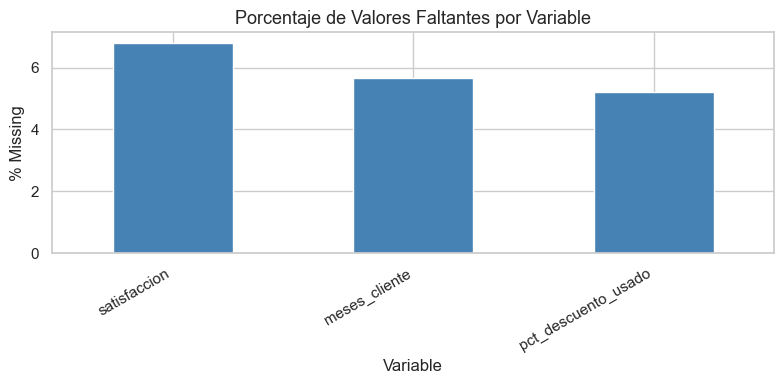

In [7]:
# Conteo y porcentaje de valores faltantes por columna
missing = pd.DataFrame({
    'Valores faltantes': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Valores faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)
print(missing)

# Visualización
if not missing.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    missing['Porcentaje (%)'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Porcentaje de Valores Faltantes por Variable', fontsize=13)
    ax.set_ylabel('% Missing')
    ax.set_xlabel('Variable')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

**Interpretación:**

Tras ejecutar el análisis, se nos presento dentro del dataset un bajo nivel general de valores faltantes (ya que ninguno supera el 7%), la razón de esto es la siguiente:

- **'satisfaccion'** (6.80%): Es normal en el retail, ya que corresponde a encuestas post-venta o a calificaciones de la app. Encuestas que no todos los clientes están dispuestos a contestar.
- **'meses_cliente'** (5.67%): Esto puede deberse a clientes que son excesivamente nuevos que aún no completan un mes.
- **'pct_descuento_usado'** (5.20%): Esto es muy probable de que los valores vacíos no sean "errores" del sistema, sino que pueden ser aquellos clientes que nunca han utilizado un cupón de descuento. Por lo que el valor real de nulos deberia ser de 0%.

## 2.5 Análisis de Distribuciones

> _(Analicen la distribución de las variables numéricas. ¿Tienen distribución normal? ¿Están sesgadas? ¿Qué implica eso para el preprocesamiento?)_

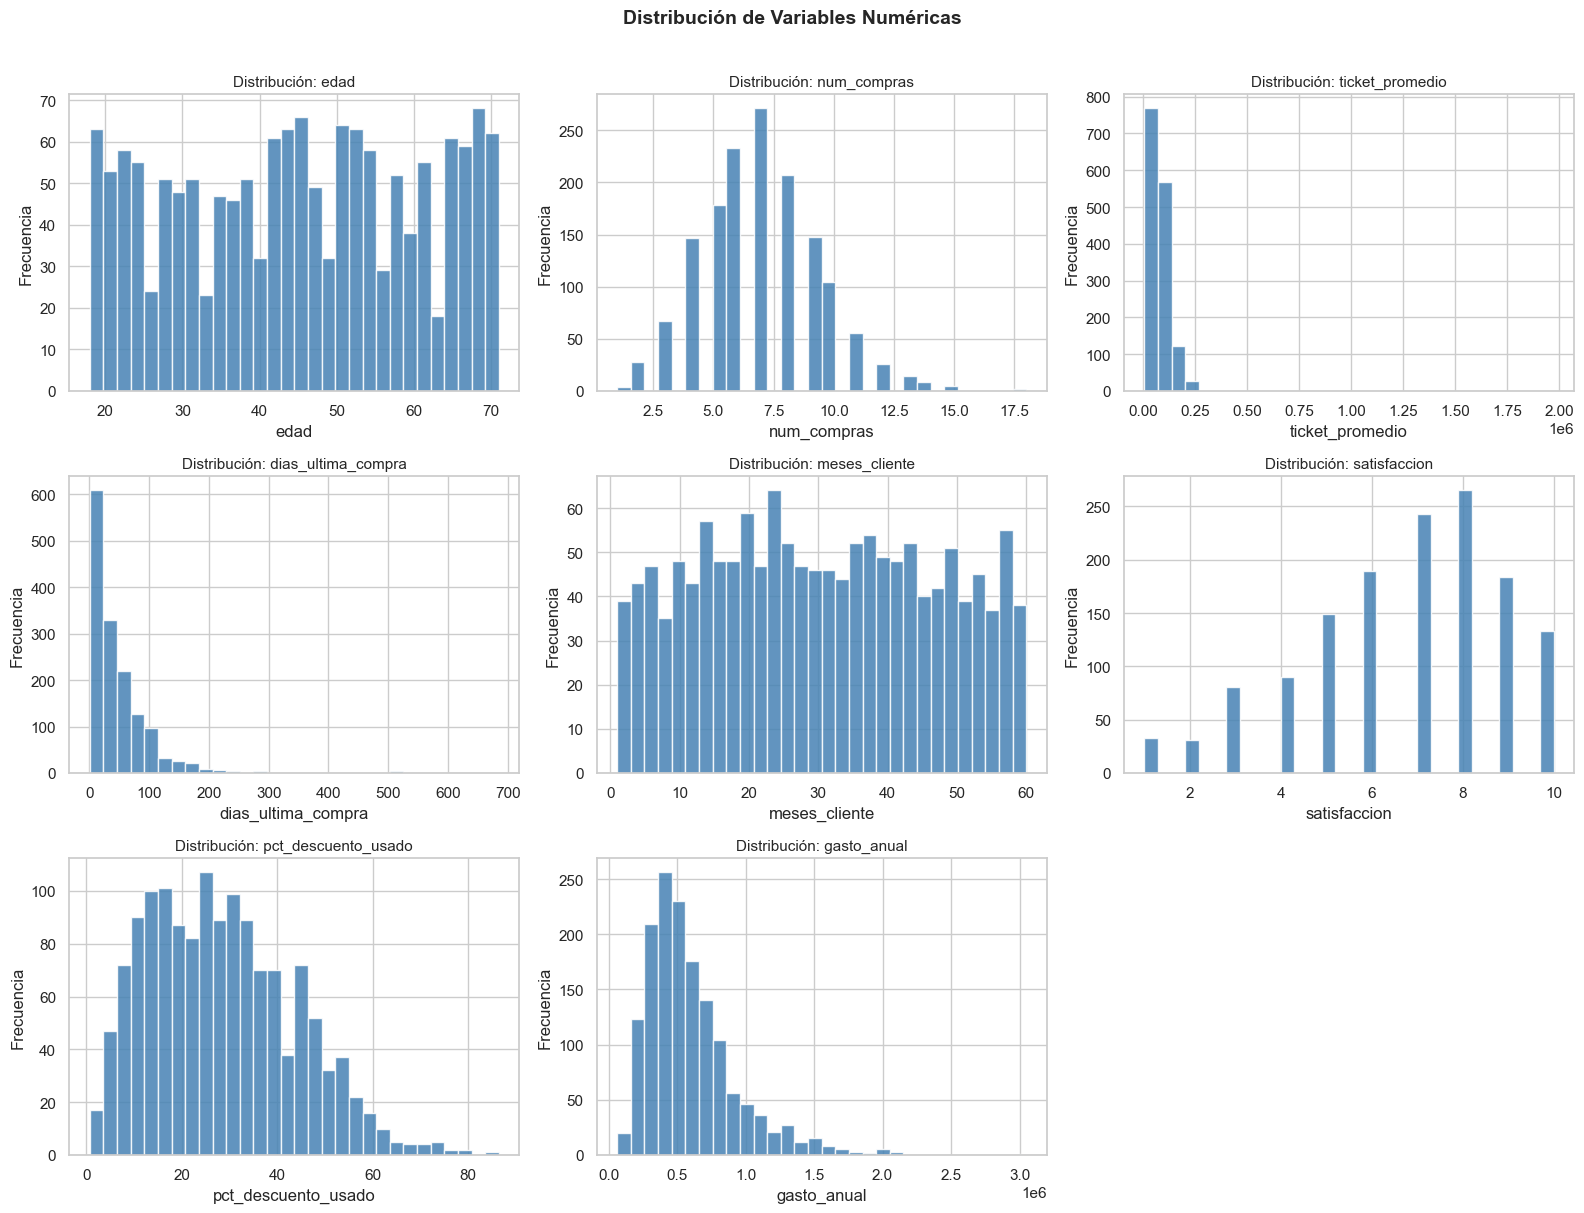

In [8]:
# Distribución de todas las variables numéricas
numericas = df.select_dtypes(include=[np.number]).columns.tolist()
# Excluimos columnas binarias y de ID para el histograma
numericas_plot = [c for c in numericas if c not in ['programa_fidelidad', 'cliente_activo']]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numericas_plot):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribución: {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Ocultar ejes sobrantes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretación:**
Al analizar las distribuciones numéricas mediante sus histogramas y el cálculo de sesgo, podemos agrupar las variables en tres comportamientos distintos, lo cual determinará nuestra estrategia de escalamiento en la siguiente fase:

- **Distribución Uniforme/Simétrica**: La variable edad presenta una distribución plana. Esto indica que no hay un grupo etario dominante, sino que la cantidad de clientes está distribuida de manera pareja entre los 20 y 60 años. Del mismo modo, meses_cliente tiene una forma simétrica.

- **Distribución Sesgada a la Derecha (Positiva)**: Las variables transaccionales y financieras (num_compras, ticket_promedio, dias_ultima_compra, pct_descuento_usado y el target gasto_anual) presentan un fuerte sesgo a la derecha. Esto se evidencia porque la gran mayoría de los clientes se agrupa en valores bajos (a la izquierda), pero existe una "larga cola" hacia la derecha compuesta por pocos clientes que gastan o compran muchísimo.

- **Distribución Sesgada a la Izquierda (Negativa)**: La variable satisfaccion presenta la mayoría de sus datos agrupados en las notas más altas (a la derecha), con una cola menor hacia la izquierda (notas bajas).

¿Influye esto en qué técnica de escalamiento usar?
Totalmente. Para las variables simétricas (como la edad), podemos usar métodos de escalamiento básicos para llevar los datos a una escala estándar (por ejemplo, entre 0 y 1). Sin embargo, para las variables financieras que están fuertemente sesgadas y tienen valores extremos en su cola (los clientes VIP que gastan millones), un escalamiento básico se distorsionaría intentando acomodar esos números gigantes. Por lo tanto, para esas columnas deberemos usar técnicas de escalamiento más robustas, diseñadas específicamente para no dejarse afectar por los valores atípicos (outliers).


## 2.6 Análisis de Variables Categóricas

C:\Users\alarc\AppData\Local\Temp\ipykernel_32028\1040265483.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include='object').columns.tolist()


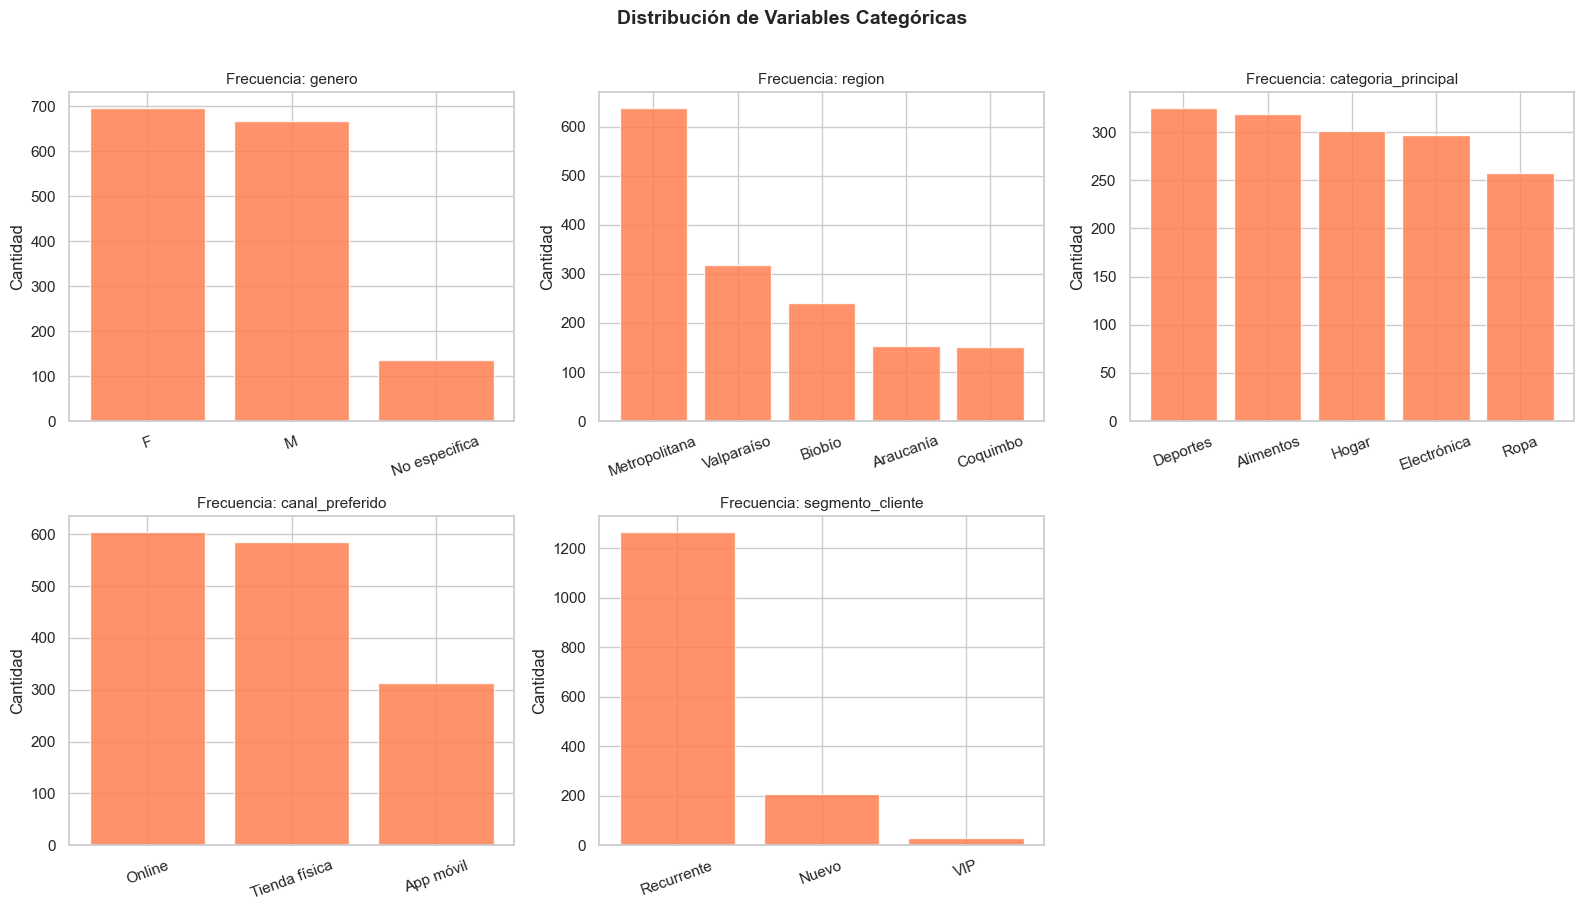

In [9]:
# Frecuencia de categorías en variables categóricas
categoricas = df.select_dtypes(include='object').columns.tolist()
categoricas = [c for c in categoricas if c != 'id_cliente']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(categoricas):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='coral', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Frecuencia: {col}', fontsize=11)
    axes[i].set_ylabel('Cantidad')
    axes[i].tick_params(axis='x', rotation=20)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de Variables Categóricas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretación**


Al analizar la distribución de las variables categóricas, llegamos a las siguientes conclusiones:

- **Frecuencia 'genero'**: Hay una baja frecuencia en la opción "No especifica". Esto no debería generar un problema grave, ya que simplemente representa a clientes que omitieron el dato. El modelo podrá segmentar bien utilizando estas tres categorías.

- **Frecuencia 'region' (Categoría Dominante)**: La Región Metropolitana domina absolutamente la muestra. Implicancia: Esto puede afectar al modelo (sesgo de representación), ya que aprenderá muy bien los patrones de los clientes de la RM y dará buenos resultados allí, pero podría carecer de precisión al predecir a los clientes de las otras regiones.

- **Frecuencia 'categoria_principal'**: Esta distribución es bastante uniforme. No hay una categoría que domine ni una con muy poca frecuencia, por lo que está balanceada y no genera implicaciones negativas para el modelo.

- **Frecuencia 'canal_preferido'**: Existe una baja frecuencia en la categoría de App Móvil respecto a las compras Online y en Tienda Física. Implicancia: Al tener menos registros, el modelo tendrá menos información para aprender los patrones específicos de los usuarios que prefieren la aplicación.

- **Frecuencia 'segmento_cliente'**: Hay una gran diferencia de volumen entre las categorías 'Recurrente' (que es la gran mayoría), 'Nuevo' y 'VIP'. Implicancia: Este desbalance de clases puede afectar de gran manera al modelo, ya que podría sesgarse a predecir siempre "Recurrente" por ser la opción más probable estadísticamente.

## 2.7 Detección de Valores Atípicos (Outliers)

> _(Usen boxplots para identificar outliers visualmente. Luego calculen los límites con IQR para cuantificarlos.)_

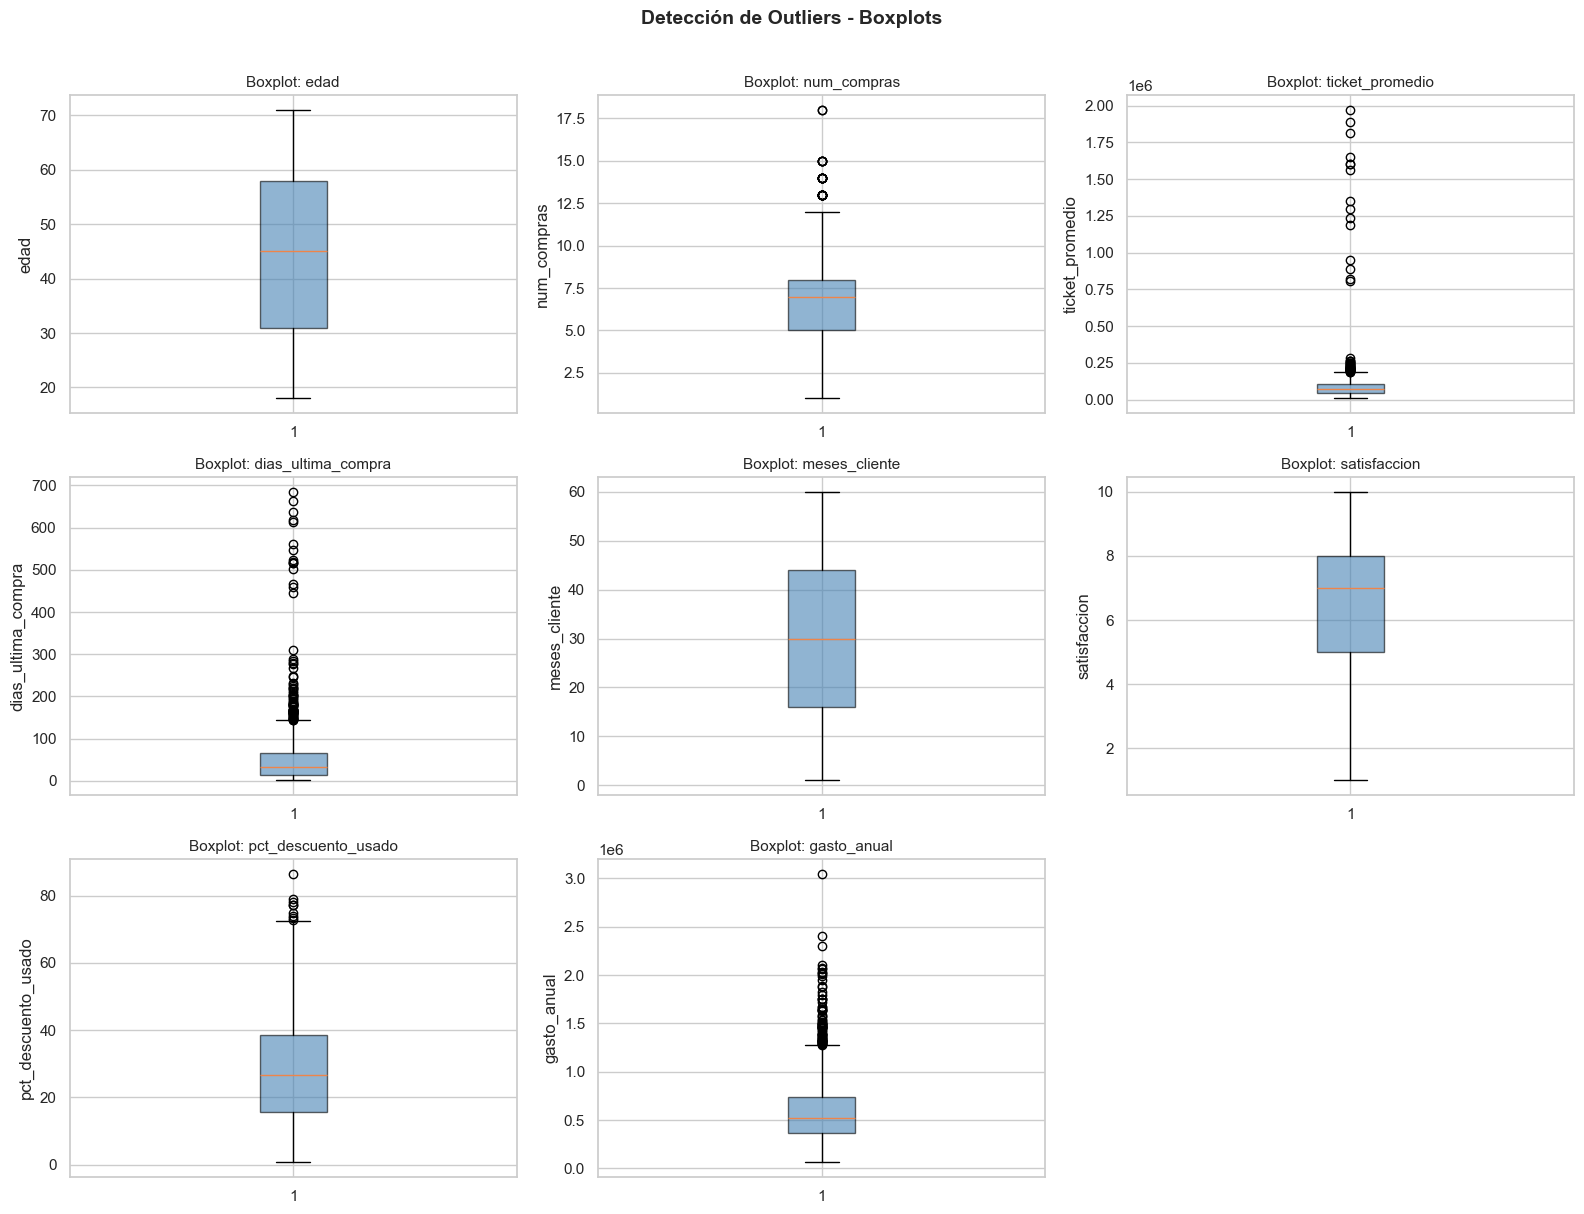

In [10]:
# Boxplots de variables numéricas para detectar outliers
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numericas_plot):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'Boxplot: {col}', fontsize=11)
    axes[i].set_ylabel(col)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Detección de Outliers - Boxplots', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# Cuantificación de outliers usando el método IQR
print('--- Outliers detectados por método IQR ---\n')
for col in numericas_plot:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < limite_inf) | (df[col] > limite_sup)).sum()
    pct = round(n_outliers / len(df) * 100, 2)
    if n_outliers > 0:
        print(f'{col:<25} → {n_outliers:>4} outliers ({pct}%) | Límites: [{limite_inf:,.0f} , {limite_sup:,.0f}]')

--- Outliers detectados por método IQR ---

num_compras               →   30 outliers (2.0%) | Límites: [0 , 12]
ticket_promedio           →   51 outliers (3.4%) | Límites: [-36,200 , 188,000]
dias_ultima_compra        →   77 outliers (5.13%) | Límites: [-64 , 144]
pct_descuento_usado       →    9 outliers (0.6%) | Límites: [-18 , 73]
gasto_anual               →   76 outliers (5.07%) | Límites: [-176,075 , 1,279,525]


**Interpretación**:

Las variables con outliers representan valores reales extremos del negocio, no errores de datos. Se tratarán de la siguiente manera:

- **'num_compras' y 'ticket_promedio'**: Representan clientes con alta frecuencia o compras muy caras. Se mantendrán, pero ajustándolos con un tope superior (winsorización) para que no distorsionen el modelo.

- **'dias_ultima_compra'**: Representa clientes inactivos por largos periodos, algo común en retail. Se mantendrán intactos, ya que eliminarlos supondría una pérdida considerable de datos (5.13%).

- **'pct_descuento_usado'**: Representa a clientes VIP que optan por mayores descuentos. Se mantendrán, pero limitándolos con un tope superior (winsorización).

- **'gasto_anual'**: Son clientes de altísimo valor. A diferencia de las anteriores, estos outliers se mantendrán intactos y sin límites. Al ser nuestra variable objetivo (Target) para la regresión, necesitamos que el modelo aprenda a predecir la realidad de estos ingresos excepcionales sin techos artificiales.

## 2.8 Análisis de Correlación

> _(El mapa de calor muestra qué variables numéricas están relacionadas entre sí. Esto es relevante para el modelado posterior.)_

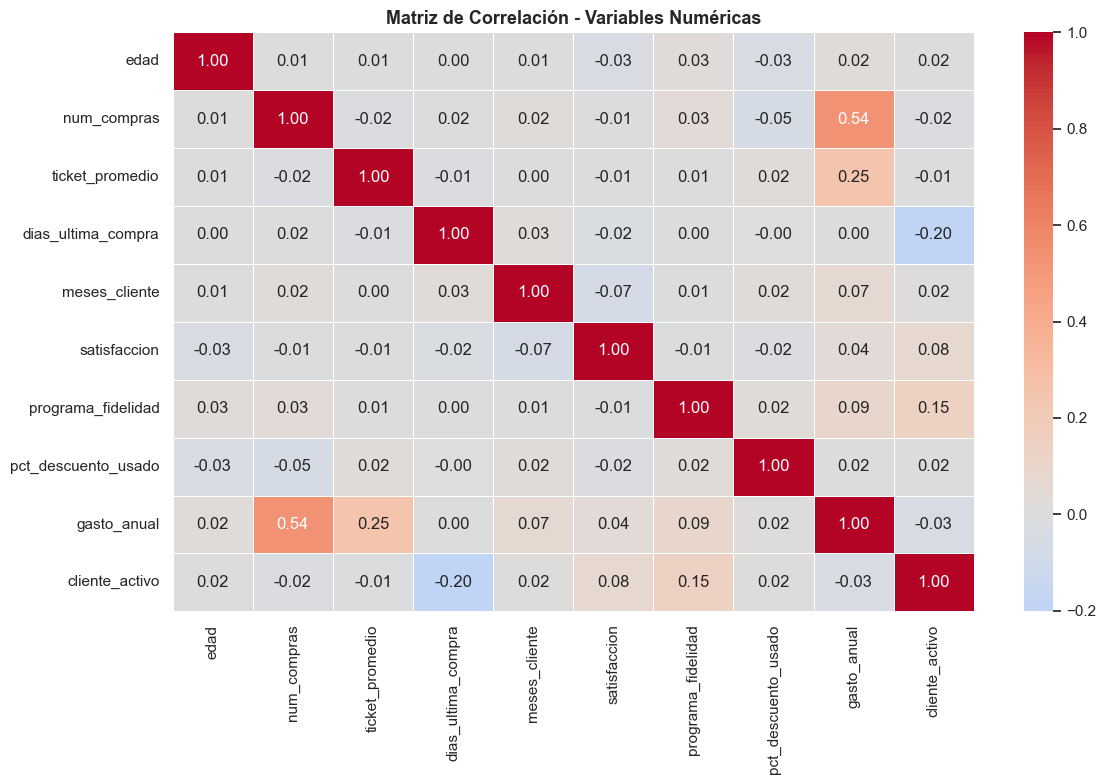

In [12]:
# Matriz de correlación entre variables numéricas
corr_matrix = df[numericas].corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, ax=ax
)
ax.set_title('Matriz de Correlación - Variables Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretación**:

Al analizar el mapa de calor, concluimos lo siguiente:

- **Relación con el Target**: La variable num_compras es la única que presenta una correlación moderadamente alta (0.54) con nuestro target (gasto_anual). Esto indica que será la variable predictora más importante para el modelo de regresión.

- **Multicolinealidad**: No existe riesgo de multicolinealidad. Este problema solo ocurre cuando las variables independientes están muy correlacionadas entre sí, y en nuestro caso, todas las relaciones entre predictoras (ej. edad vs ticket_promedio) son cercanas a 0.

---
# FASE 3 — Preparación de los Datos
### `CRISP-DM: Data Preparation`

En esta fase transformamos los datos crudos en un dataset listo para modelar.  
Cada decisión debe estar **justificada** en las celdas markdown.

In [ ]:
# Trabajamos sobre una copia para preservar el dataset original
df_prep = df.copy()
print(f'Copia creada: {df_prep.shape[0]:,} filas x {df_prep.shape[1]} columnas')

## 3.1 Tratamiento de Missing Values

> **Justificación de la estrategia elegida:**  
> _(Expliquen por qué eligieron cada método para cada variable. Opciones comunes: mediana, media, moda, KNN, eliminación de filas. El criterio debe basarse en la distribución y el significado de negocio de cada variable.)_

In [ ]:
# -------------------------------------------------------
# COMPLETEN ESTE BLOQUE con la estrategia que elijan
# -------------------------------------------------------

# Ejemplo para 'satisfaccion' con mediana:
# mediana_satisfaccion = df_prep['satisfaccion'].median()
# df_prep['satisfaccion'].fillna(mediana_satisfaccion, inplace=True)

# Ejemplo para 'meses_cliente' con KNN:
# from sklearn.impute import KNNImputer
# imputer = KNNImputer(n_neighbors=5)
# df_prep[['meses_cliente']] = imputer.fit_transform(df_prep[['meses_cliente']])

# Verifica que no queden missing values
print('Missing values restantes:')
print(df_prep.isnull().sum()[df_prep.isnull().sum() > 0])

## 3.2 Tratamiento de Outliers

> **Justificación de la estrategia elegida:**  
> _(¿Eliminaron filas, aplicaron winsorización, o los dejaron? Justifiquen cada decisión en función del contexto de negocio.)_

In [ ]:
# -------------------------------------------------------
# COMPLETEN ESTE BLOQUE con la estrategia que elijan
# -------------------------------------------------------

# Ejemplo de winsorización para 'ticket_promedio':
# Q1 = df_prep['ticket_promedio'].quantile(0.25)
# Q3 = df_prep['ticket_promedio'].quantile(0.75)
# IQR = Q3 - Q1
# limite_sup = Q3 + 1.5 * IQR
# df_prep['ticket_promedio'] = df_prep['ticket_promedio'].clip(upper=limite_sup)

print(f'Filas después del tratamiento de outliers: {len(df_prep):,}')

## 3.3 Encoding de Variables Categóricas

> **Justificación:**  
> _(¿Qué variables categóricas codificaron? ¿Usaron LabelEncoder u OneHotEncoder? La elección depende de si la variable es nominal u ordinal.)_

In [ ]:
# -------------------------------------------------------
# COMPLETEN ESTE BLOQUE con la estrategia que elijan
# -------------------------------------------------------

# Ejemplo LabelEncoder para variable ordinal:
# le = LabelEncoder()
# df_prep['genero_enc'] = le.fit_transform(df_prep['genero'])

# Ejemplo OneHotEncoder para variable nominal:
# df_prep = pd.get_dummies(df_prep, columns=['region'], prefix='region')

print('Columnas después del encoding:')
print(df_prep.columns.tolist())

## 3.4 Escalamiento de Variables Numéricas

> **Justificación:**  
> _(¿Usaron StandardScaler o MinMaxScaler? La decisión debe basarse en la distribución de los datos observada en la Fase 2. Variables con distribución normal → StandardScaler. Variables acotadas o con outliers → MinMaxScaler.)_

In [ ]:
# -------------------------------------------------------
# COMPLETEN ESTE BLOQUE con la estrategia que elijan
# -------------------------------------------------------

# Variables a escalar (excluir targets y variables binarias)
# vars_escalar = ['edad', 'num_compras', 'ticket_promedio',
#                 'dias_ultima_compra', 'meses_cliente',
#                 'satisfaccion', 'pct_descuento_usado']

# Ejemplo con StandardScaler:
# scaler = StandardScaler()
# df_prep[vars_escalar] = scaler.fit_transform(df_prep[vars_escalar])

print('Estadísticos después del escalamiento:')
# print(df_prep[vars_escalar].describe().T)

## 3.5 Verificación Final del Dataset Procesado

> _(Verifiquen que el dataset está listo: sin missing values, variables codificadas, variables escaladas.)_

In [ ]:
print('=== RESUMEN DEL DATASET PROCESADO ===')
print(f'Dimensiones       : {df_prep.shape}')
print(f'Missing values    : {df_prep.isnull().sum().sum()}')
print(f'Tipos de datos    :')
print(df_prep.dtypes)
print()
df_prep.head()

---
# Conclusiones de la Entrega 1

> _(Escriban al menos 5 conclusiones relevantes que conecten los hallazgos técnicos con el contexto de negocio de RetailSmart. Ejemplo: qué descubrieron sobre el comportamiento de los clientes, qué variables parecen más relevantes, qué decisiones de preprocesamiento tomaron y por qué.)_

1. ...
2. ...
3. ...
4. ...
5. ...

---
*Machine Learning - MLY0100 | DUOC UC | Semestre 2025*